<a href="https://colab.research.google.com/github/jd200-durga/Skin_Disease_Detection_Using_DeepLearning/blob/main/skin_disease_detection_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, cv2, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))
print('✅ All packages installed successfully!')

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ All packages installed successfully!


In [ ]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 761.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 124.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 96.8 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 18.9 MB/s eta 0:00:00


In [ ]:
from google.colab import files
print('Upload your kaggle.json file:')
uploaded = files.upload()

Upload your kaggle.json file:


Saving HAM10000_folders.zip to HAM10000_folders.zip


In [ ]:
import zipfile
import os

zip_file = "HAM10000_folders.zip"

os.makedirs("/content/HAM10000_folders", exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as z:
    z.extractall("/content/HAM10000_folders")

print("Extracted successfully!")
print(os.listdir("/content/HAM10000_folders"))

Extracted successfully!
['HAM10000_folders']


In [ ]:
data_dir = "/content/ham10000"

In [ ]:
import os
print(os.listdir("/content/HAM10000_folders"))
print(os.listdir("/content/HAM10000_folders"))

['HAM10000_folders']
['HAM10000_folders']


In [ ]:
import os
print(os.listdir("/content/HAM10000_folders/HAM10000_folders"))

['df', 'bcc', 'akiec', 'vasc', 'nv', 'bkl', 'mel']


In [ ]:
import os
import pandas as pd

base_path = "/content/HAM10000_folders/HAM10000_folders"

data = []

for label in os.listdir(base_path):
    folder_path = os.path.join(base_path, label)

    if os.path.isdir(folder_path):
        for img in os.listdir(folder_path):
            if img.endswith(".jpg"):
                image_id = img.split(".")[0]
                data.append([image_id, label])

# create dataframe
df_generated = pd.DataFrame(data, columns=["image_id", "dx"])

# save as CSV in your expected location
os.makedirs("/content/ham10000", exist_ok=True)
csv_path = "/content/ham10000/HAM10000_metadata.csv"
df_generated.to_csv(csv_path, index=False)

print("CSV created at:", csv_path)
print(df_generated.head())

CSV created at: /content/ham10000/HAM10000_metadata.csv
       image_id  dx
0  ISIC_0027626  df
1  ISIC_0031257  df
2  ISIC_0029578  df
3  ISIC_0033554  df
4  ISIC_0025373  df


CSVs found: ['/content/ham10000/HAM10000_metadata.csv']
Shape: (10015, 2)
       image_id  dx
0  ISIC_0027626  df
1  ISIC_0031257  df
2  ISIC_0029578  df
3  ISIC_0033554  df
4  ISIC_0025373  df

Class counts:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


/tmp/ipykernel_1628/3730128375.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="dx", order=df["dx"].value_counts().index, palette="Set2")


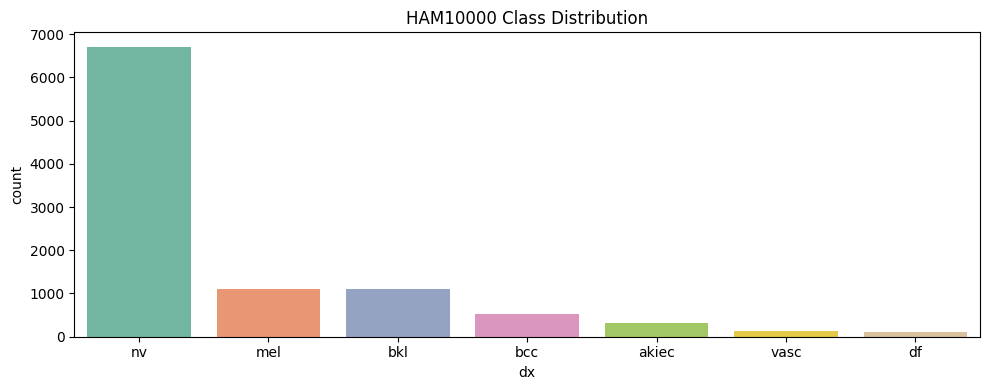

Phase 2 done!


In [ ]:
import glob
import matplotlib.pyplot as plt
import seaborn as sns

csv_files = glob.glob("/content/ham10000/HAM10000_metadata.csv", recursive=True)
print("CSVs found:", csv_files)

df = pd.read_csv(csv_files[0])
print("Shape:", df.shape)
print(df.head())
print("\nClass counts:")
print(df["dx"].value_counts())

LABEL_MAP = {
    "nv":    "Melanocytic Nevi",
    "mel":   "Melanoma",
    "bkl":   "Benign Keratosis",
    "bcc":   "Basal Cell Carcinoma",
    "akiec": "Actinic Keratosis",
    "vasc":  "Vascular Lesion",
    "df":    "Dermatofibroma"
}
NUM_CLASSES = len(LABEL_MAP)

df["label"] = df["dx"]
df["label_name"] = df["dx"].map(LABEL_MAP)

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="dx", order=df["dx"].value_counts().index, palette="Set2")
plt.title("HAM10000 Class Distribution")
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=100)
plt.show()
print("Phase 2 done!")

Total images found: 10015
Matched images: 10015
Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


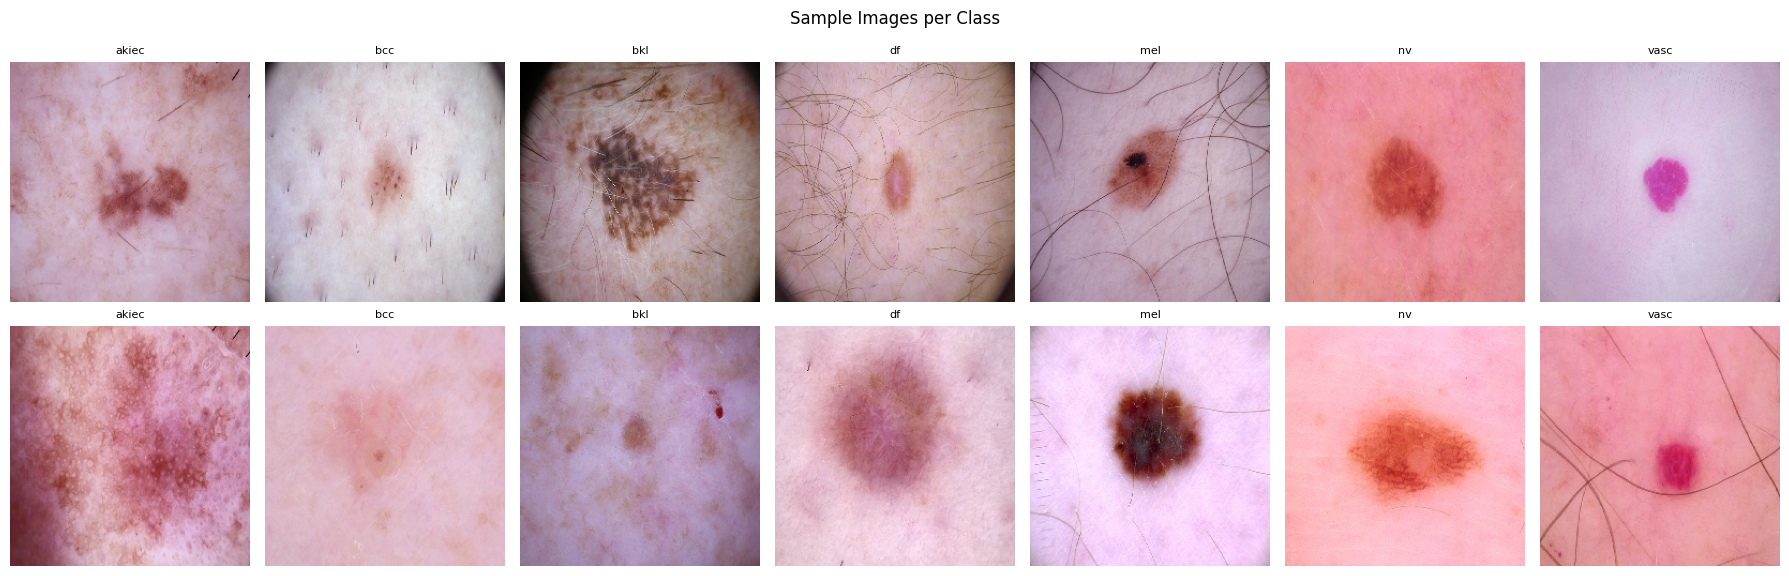

Phase 3 done!


In [ ]:
#Image Preprocessing
from sklearn.preprocessing import LabelEncoder
import glob
import cv2
import matplotlib.pyplot as plt

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Find all images
image_paths = glob.glob("/content/HAM10000_folders/**/*.jpg", recursive=True)
print(f"Total images found: {len(image_paths)}")

# Map image_id to file path
id_to_path = {}
for p in image_paths:
    img_id = os.path.splitext(os.path.basename(p))[0]
    id_to_path[img_id] = p

df["filepath"] = df["image_id"].map(id_to_path)
df = df.dropna(subset=["filepath"]).reset_index(drop=True)
print(f"Matched images: {len(df)}")

# Encode labels
le = LabelEncoder()
df["encoded_label"] = le.fit_transform(df["label"])
CLASS_NAMES = list(le.classes_)
print("Classes:", CLASS_NAMES)

# Show sample images
fig, axes = plt.subplots(2, 7, figsize=(18, 6))
for i, cls in enumerate(CLASS_NAMES):
    samples = df[df["label"] == cls].sample(2, random_state=42)
    for j, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, IMG_SIZE)
        axes[j][i].imshow(img)
        axes[j][i].set_title(cls, fontsize=8)
        axes[j][i].axis("off")
plt.suptitle("Sample Images per Class")
plt.tight_layout()
plt.show()
print("Phase 3 done!")

In [ ]:
#data augmentation.
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json

# Balance classes by oversampling minority classes
max_count = df["label"].value_counts().max()
balanced_dfs = []
for cls in CLASS_NAMES:
    cls_df = df[df["label"] == cls]
    if len(cls_df) < max_count:
        cls_df = cls_df.sample(max_count, replace=True, random_state=42)
    balanced_dfs.append(cls_df)

df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
print("Balanced shape:", df_balanced.shape)
print(df_balanced["label"].value_counts())

# Train / Val / Test split
train_df, temp_df = train_test_split(df_balanced, test_size=0.3, stratify=df_balanced["label"], random_state=42)
val_df,   test_df = train_test_split(temp_df,     test_size=0.5, stratify=temp_df["label"],     random_state=42)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

# Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=True
)
val_gen = val_datagen.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
test_gen = val_datagen.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label",
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

CLASS_INDICES = train_gen.class_indices
IDX_TO_CLASS  = {v: k for k, v in CLASS_INDICES.items()}

with open("/content/class_indices.json", "w") as f:
    json.dump(IDX_TO_CLASS, f)

print("Class indices:", CLASS_INDICES)
print("Phase 4 done!")

Balanced shape: (46935, 6)
label
df       6705
nv       6705
bcc      6705
mel      6705
vasc     6705
bkl      6705
akiec    6705
Name: count, dtype: int64
Train: 32854 | Val: 7040 | Test: 7041
Found 32854 validated image filenames belonging to 7 classes.
Found 7040 validated image filenames belonging to 7 classes.
Found 7041 validated image filenames belonging to 7 classes.
Class indices: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Phase 4 done!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam

base_model = VGG19(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze first 15 layers
for layer in base_model.layers[:15]:
    layer.trainable = False
for layer in base_model.layers[15:]:
    layer.trainable = True

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()
print("Phase 5 done!")

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,423,239 (77.91 MB)

 Trainable params: 12,196,359 (46.53 MB)

 Non-trainable params: 8,226,880 (31.38 MB)

Phase 5 done!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt

EPOCHS = 30

callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint("/content/medscan_vgg19_best.h5", monitor="val_accuracy", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

# Plot curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history.history["accuracy"],     label="Train"); axes[0].plot(history.history["val_accuracy"], label="Val"); axes[0].set_title("Accuracy"); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history.history["loss"],         label="Train"); axes[1].plot(history.history["val_loss"],      label="Val"); axes[1].set_title("Loss");     axes[1].legend(); axes[1].grid(True)
axes[2].plot(history.history["auc"],          label="Train"); axes[2].plot(history.history["val_auc"],       label="Val"); axes[2].set_title("AUC");      axes[2].legend(); axes[2].grid(True)
plt.tight_layout()
plt.savefig("/content/training_history.png", dpi=100)
plt.show()
print("Training complete!")

NameError: name 'model' is not defined

In [ ]:
model = load_model("/content/medscan_vgg19_best.h5")

loss, acc, auc = model.evaluate(test_gen, verbose=1)
print(f"\nTest Accuracy : {acc*100:.2f}%")
print(f"Test AUC      : {auc:.4f}")
print(f"Test Loss     : {loss:.4f}")

y_pred = np.argmax(model.predict(test_gen, verbose=1), axis=1)
y_true = test_gen.classes
labels = list(test_gen.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=labels))

cm_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=100)
plt.show()
print("Phase 7 done!")

In [ ]:
def predict_image(image_path):
    img = Image.open(image_path).convert("RGB").resize((224, 224))
    arr = np.expand_dims(np.array(img) / 255.0, axis=0)
    probs = model.predict(arr, verbose=0)[0]
    idx = np.argmax(probs)
    return IDX_TO_CLASS[idx], round(float(probs[idx]) * 100, 2)

# Test on one sample
sample = test_df.sample(1).iloc[0]
pred, conf = predict_image(sample["filepath"])
print(f"True  : {sample['label']}")
print(f"Pred  : {pred}")
print(f"Conf  : {conf}%")

plt.imshow(Image.open(sample["filepath"]))
plt.title(f"{pred} ({conf}%)")
plt.axis("off")
plt.show()
print("Phase 8 done!")

In [ ]:
def get_gradcam(image_path):
    orig = np.array(Image.open(image_path).convert("RGB").resize((224, 224)))
    tensor = np.expand_dims(orig / 255.0, 0).astype("float32")

    grad_model = Model(
        inputs=model.inputs,
        outputs=[model.get_layer("block5_conv4").output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(tensor)
        pred_idx = tf.argmax(preds[0])
        loss = preds[:, pred_idx]

    grads   = tape.gradient(loss, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    hm_resized  = cv2.resize(heatmap, (224, 224))
    hm_colored  = np.uint8(255 * cm.jet(hm_resized)[:, :, :3])
    overlay     = cv2.addWeighted(orig, 0.6, hm_colored, 0.4, 0)

    pred_class  = IDX_TO_CLASS[int(np.argmax(preds[0]))]
    confidence  = float(tf.reduce_max(preds[0])) * 100

    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    axes[0].imshow(orig);       axes[0].set_title("Original");        axes[0].axis("off")
    axes[1].imshow(hm_colored); axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis("off")
    axes[2].imshow(overlay);    axes[2].set_title(f"{pred_class} ({confidence:.1f}%)"); axes[2].axis("off")
    plt.suptitle("Grad-CAM Visualization", fontsize=14)
    plt.tight_layout()
    plt.savefig("/content/gradcam_output.png", dpi=120)
    plt.show()

# Run on a random test image
get_gradcam(test_df.sample(1).iloc[0]["filepath"])
print("Phase 9 done!")

In [ ]:
os.makedirs("/content/templates", exist_ok=True)

app_code = '''
import os, json, base64, io
import numpy as np
from PIL import Image
from flask import Flask, request, jsonify
import tensorflow as tf
import cv2
import matplotlib
matplotlib.use("Agg")
import matplotlib.cm as cm

app = Flask(__name__)
model = tf.keras.models.load_model("/content/medscan_vgg19_best.h5")
with open("/content/class_indices.json") as f:
    IDX_TO_CLASS = {int(k): v for k, v in json.load(f).items()}

LABEL_MAP = {
    "nv":"Melanocytic Nevi","mel":"Melanoma","bkl":"Benign Keratosis",
    "bcc":"Basal Cell Carcinoma","akiec":"Actinic Keratosis",
    "vasc":"Vascular Lesion","df":"Dermatofibroma"
}

def to_b64(arr):
    buf = io.BytesIO()
    Image.fromarray(arr.astype("uint8")).save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode()

@app.route("/")
def index():
    return open("/content/templates/index.html").read(), 200, {"Content-Type":"text/html"}

@app.route("/predict", methods=["POST"])
def predict():
    file = request.files.get("file")
    if not file:
        return jsonify({"error":"No file"}), 400
    try:
        orig = np.array(Image.open(file).convert("RGB").resize((224,224)))
        tensor = np.expand_dims(orig/255.0, 0).astype("float32")
        preds = model.predict(tensor, verbose=0)[0]
        idx = int(np.argmax(preds))
        code = IDX_TO_CLASS[idx]
        name = LABEL_MAP.get(code, code)
        conf = round(float(preds[idx])*100, 2)
        all_probs = sorted([
            {"code":IDX_TO_CLASS[i],"name":LABEL_MAP.get(IDX_TO_CLASS[i],IDX_TO_CLASS[i]),"prob":round(float(preds[i])*100,2)}
            for i in range(len(preds))
        ], key=lambda x: x["prob"], reverse=True)

        # Grad-CAM
        from tensorflow.keras.models import Model as KModel
        gm = KModel(inputs=model.inputs,
                    outputs=[model.get_layer("block5_conv4").output, model.output])
        with tf.GradientTape() as tape:
            co, ps = gm(tensor)
            loss = ps[:, idx]
        grads   = tape.gradient(loss, co)
        pooled  = tf.reduce_mean(grads, axis=(0,1,2))
        hm      = co[0] @ pooled[..., tf.newaxis]
        hm      = tf.squeeze(hm)
        hm      = tf.maximum(hm,0) / (tf.math.reduce_max(hm)+1e-8)
        hm      = cv2.resize(hm.numpy(), (224,224))
        hm_col  = np.uint8(255 * cm.jet(hm)[:,:,:3])
        overlay = cv2.addWeighted(orig, 0.55, hm_col, 0.45, 0)

        return jsonify({
            "prediction": name, "code": code, "confidence": conf,
            "all_probs": all_probs,
            "original_img": to_b64(orig),
            "heatmap_img":  to_b64(hm_col),
            "overlay_img":  to_b64(overlay)
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 500

if __name__ == "__main__":
    app.run(port=5000, debug=False)
'''

with open("/content/app.py", "w") as f:
    f.write(app_code)
print("app.py saved!")

In [ ]:
html = open("/content/templates/index.html", "w")
html.write("""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>MedScan AI: Skin Lesion Diagnostic Portal</title>
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&display=swap" rel="stylesheet">
<style>
*{box-sizing:border-box;margin:0;padding:0}
:root{--bg:#eef2f7;--w:#fff;--pri:#1a6fc4;--prid:#155a9e;--suc:#2e9e5b;--txt:#1e2a3b;--mut:#6b7a8f;--brd:#dde3eb}
body{font-family:"Inter",sans-serif;background:var(--bg);color:var(--txt)}
.topbar{position:fixed;top:0;left:0;right:0;height:56px;background:var(--w);border-bottom:1px solid var(--brd);display:flex;align-items:center;justify-content:space-between;padding:0 24px;z-index:100}
.logo{display:flex;align-items:center;gap:8px;font-weight:700;color:var(--pri);font-size:1.1rem}
.sidebar{position:fixed;top:56px;left:0;bottom:0;width:220px;background:var(--w);border-right:1px solid var(--brd);padding:16px 10px;display:flex;flex-direction:column;gap:2px}
.nav{display:flex;align-items:center;gap:10px;padding:9px 12px;border-radius:8px;color:var(--mut);font-size:.88rem;font-weight:500;cursor:pointer;text-decoration:none}
.nav:hover{background:var(--bg);color:var(--pri)}.nav.active{background:#e8f0fb;color:var(--pri)}
.main{margin-left:220px;margin-top:56px;padding:28px 32px}
.ph{display:flex;justify-content:space-between;align-items:center;margin-bottom:24px}
.ph h1{font-size:1.5rem;font-weight:700}
.btns{display:flex;gap:10px}
.btn{padding:9px 18px;border-radius:8px;font-size:.88rem;font-weight:600;cursor:pointer;border:none}
.bp{background:var(--pri);color:#fff}.bp:hover{background:var(--prid)}
.bo{background:var(--w);border:1px solid var(--brd);color:var(--txt)}.bo:hover{background:var(--bg)}
.grid{display:grid;grid-template-columns:1fr 1fr;gap:24px}
.card{background:var(--w);border-radius:14px;padding:24px;border:1px solid var(--brd)}
.ct{font-size:1rem;font-weight:700;margin-bottom:18px}
.uz{border:2px dashed var(--brd);border-radius:12px;padding:36px 20px;text-align:center;cursor:pointer;background:#f8fafc;transition:.2s}
.uz:hover,.dov{border-color:var(--pri)!important;background:#eef4fb!important}
.uz p{font-size:.88rem;color:var(--mut);line-height:1.6;margin-top:8px}
.fmts{display:flex;gap:8px;justify-content:center;margin-top:10px}
.fmt{background:var(--w);border:1px solid var(--brd);border-radius:6px;padding:3px 10px;font-size:.75rem;font-weight:600;color:var(--mut)}
.fp{display:none;align-items:center;gap:12px;margin-top:12px;background:#f8fafc;border-radius:10px;padding:10px 14px;border:1px solid var(--brd)}
.fp.show{display:flex}
.fthumb{width:48px;height:48px;border-radius:8px;object-fit:cover}
.fname{font-weight:600;font-size:.88rem}.fsize{color:var(--mut);font-size:.78rem;margin-top:2px}
.fdel{background:none;border:none;cursor:pointer;color:var(--mut);font-size:1rem;margin-left:auto}
.bua{width:100%;margin-top:14px;padding:12px;border-radius:10px;font-size:.95rem;font-weight:700;background:var(--suc);color:var(--w);border:none;cursor:pointer}
.bua:hover:not(:disabled){background:#247a49}.bua:disabled{background:#a0adb8;cursor:not-allowed}
.rh{display:flex;justify-content:space-between;align-items:center;margin-bottom:14px}
.badge{display:inline-flex;align-items:center;gap:5px;background:#e8faf0;color:var(--suc);border:1px solid #b6e8cc;border-radius:20px;padding:4px 12px;font-size:.78rem;font-weight:600}
.ph2{display:none;flex-direction:column;align-items:center;justify-content:center;min-height:360px;color:var(--mut);text-align:center}
.ph2 p{font-size:.88rem}
.ls{display:none;flex-direction:column;align-items:center;justify-content:center;min-height:360px;text-align:center}
.ls.show{display:flex}
.sp{width:44px;height:44px;border:4px solid var(--brd);border-top-color:var(--pri);border-radius:50%;animation:spin .8s linear infinite;margin-bottom:14px}
@keyframes spin{to{transform:rotate(360deg)}}
.rc{display:none}.rc.show{display:block}
.ip2{display:grid;grid-template-columns:1fr 1fr;gap:10px;margin-bottom:16px}
.ib img{width:100%;height:155px;object-fit:cover;border-radius:10px;border:1px solid var(--brd)}
.il{font-size:.72rem;color:var(--mut);margin-top:4px}
.pr2{display:grid;grid-template-columns:1fr 1fr;gap:14px;margin-bottom:16px}
.pb{padding:12px;border:1px solid var(--brd);border-radius:10px}
.pl{font-size:.7rem;font-weight:700;letter-spacing:.06em;color:var(--mut);text-transform:uppercase;margin-bottom:4px}
.pv{font-size:1.35rem;font-weight:800;color:var(--suc)}
.pbg{height:6px;background:var(--brd);border-radius:4px;margin-top:6px;overflow:hidden}
.pf{height:100%;background:var(--suc);border-radius:4px;transition:width .6s}
.gt{font-size:.72rem;font-weight:700;letter-spacing:.06em;color:var(--mut);text-transform:uppercase;margin-bottom:8px}
.bli .bi{margin-bottom:8px}
.bir{display:flex;justify-content:space-between;font-size:.8rem;margin-bottom:3px}
.bib{height:4px;background:var(--bg);border-radius:4px;overflow:hidden}
.bif{height:100%;background:var(--pri);border-radius:4px}
#fi{display:none}
</style>
</head>
<body>

<header class="topbar">
  <div class="logo">
    <svg width="28" height="28" viewBox="0 0 32 32" fill="none"><circle cx="16" cy="16" r="14" stroke="#1a6fc4" stroke-width="2.5"/><path d="M10 16h4l2-5 3 10 2-5h3" stroke="#1a6fc4" stroke-width="2" stroke-linecap="round" stroke-linejoin="round"/></svg>
    MedScan AI
  </div>
  <span style="font-weight:600;font-size:.95rem">MedScan AI: Skin Lesion Diagnostic Portal</span>
  <svg width="20" height="20" fill="none" stroke="#6b7a8f" stroke-width="2" viewBox="0 0 24 24"><circle cx="12" cy="8" r="4"/><path d="M4 20c0-4 3.6-7 8-7s8 3 8 7"/></svg>
</header>

<nav class="sidebar">
  <a class="nav" href="#">
    <svg width="16" height="16" fill="none" stroke="currentColor" stroke-width="2" viewBox="0 0 24 24"><rect x="3" y="3" width="7" height="7" rx="1"/><rect x="14" y="3" width="7" height="7" rx="1"/><rect x="3" y="14" width="7" height="7" rx="1"/><rect x="14" y="14" width="7" height="7" rx="1"/></svg>
    Dashboard</a>
  <a class="nav active" href="#">
    <svg width="16" height="16" fill="none" stroke="currentColor" stroke-width="2" viewBox="0 0 24 24"><path d="M21 15v4a2 2 0 0 1-2 2H5a2 2 0 0 1-2-2v-4"/><polyline points="17 8 12 3 7 8"/><line x1="12" y1="3" x2="12" y2="15"/></svg>
    Upload Image</a>
  <a class="nav" href="#">
    <svg width="16" height="16" fill="none" stroke="currentColor" stroke-width="2" viewBox="0 0 24 24"><circle cx="12" cy="12" r="10"/><line x1="12" y1="8" x2="12" y2="12"/><line x1="12" y1="16" x2="12.01" y2="16"/></svg>
    Prediction Results</a>
  <a class="nav" href="#">
    <svg width="16" height="16" fill="none" stroke="currentColor" stroke-width="2" viewBox="0 0 24 24"><path d="M17 21v-2a4 4 0 0 0-4-4H5a4 4 0 0 0-4 4v2"/><circle cx="9" cy="7" r="4"/></svg>
    Patients</a>
  <a class="nav" href="#">
    <svg width="16" height="16" fill="none" stroke="currentColor" stroke-width="2" viewBox="0 0 24 24"><line x1="18" y1="20" x2="18" y2="10"/><line x1="12" y1="20" x2="12" y2="4"/><line x1="6" y1="20" x2="6" y2="14"/></svg>
    Analytics</a>
  <a class="nav" href="#" style="margin-top:auto">
    <svg width="16" height="16" fill="none" stroke="currentColor" stroke-width="2" viewBox="0 0 24 24"><circle cx="12" cy="12" r="3"/><path d="M19.07 4.93A10 10 0 1 0 4.93 19.07"/></svg>
    Settings</a>
  <a class="nav" href="#">
    <svg width="16" height="16" fill="none" stroke="currentColor" stroke-width="2" viewBox="0 0 24 24"><path d="M9 21H5a2 2 0 0 1-2-2V5a2 2 0 0 1 2-2h4"/><polyline points="16 17 21 12 16 7"/><line x1="21" y1="12" x2="9" y2="12"/></svg>
    Logout</a>
</nav>

<main class="main">
  <div class="ph">
    <h1>Dashboard</h1>
    <div class="btns">
      <button class="btn bp" onclick="resetAll()">+ Start New Analysis</button>
      <button class="btn bo" onclick="window.print()">Print Report</button>
    </div>
  </div>

  <div class="grid">
    <!-- UPLOAD PANEL -->
    <div class="card">
      <div class="ct">1. Upload Patient Image</div>
      <div class="uz" id="uz" ondragover="dov(event)" ondragleave="dol(event)" ondrop="dop(event)" onclick="document.getElementById('fi').click()">
        <svg width="48" height="48" fill="none" stroke="#1a6fc4" stroke-width="1.5" viewBox="0 0 24 24"><path d="M21 15v4a2 2 0 0 1-2 2H5a2 2 0 0 1-2-2v-4"/><polyline points="17 8 12 3 7 8"/><line x1="12" y1="3" x2="12" y2="15"/></svg>
        <p>Drag & drop skin lesion image here or<br><strong>Click to upload</strong></p>
        <div class="fmts"><span class="fmt">JPEG</span><span class="fmt">PNG</span></div>
      </div>
      <input type="file" id="fi" accept="image/jpeg,image/png" onchange="sel(event)">
      <div class="fp" id="fp">
        <img id="pt" class="fthumb" src="" alt="">
        <div><div class="fname" id="pn"></div><div class="fsize" id="ps"></div></div>
        <button class="fdel" onclick="clr()">&#10005;</button>
      </div>
      <button class="bua" id="ab" onclick="analyze()" disabled>Upload & Analyze</button>
    </div>

    <!-- RESULTS PANEL -->
    <div class="card">
      <div class="rh">
        <div class="ct" style="margin-bottom:0">2. Prediction & Analysis</div>
        <span class="badge" id="sb" style="display:none">&#10003; Analysis Complete</span>
      </div>

      <div class="ph2" id="pls" style="display:flex">
        <svg width="52" height="52" fill="none" stroke="#6b7a8f" stroke-width="1.5" viewBox="0 0 24 24" style="opacity:.3;margin-bottom:12px"><circle cx="11" cy="11" r="8"/><line x1="21" y1="21" x2="16.65" y2="16.65"/></svg>
        <p>Upload an image to see<br>diagnosis and Grad-CAM results</p>
      </div>

      <div class="ls" id="ls">
        <div class="sp"></div>
        <p style="font-weight:600">Analyzing image...</p>
        <p style="color:#6b7a8f;font-size:.83rem;margin-top:4px">Running VGG19 + Grad-CAM</p>
      </div>

      <div class="rc" id="rc">
        <div style="margin-bottom:12px">
          <div style="font-weight:700;font-size:.9rem" id="rfn"></div>
          <div style="color:#6b7a8f;font-size:.8rem;margin-top:2px">Patient ID: <span id="rpid"></span></div>
        </div>
        <div class="ip2">
          <div class="ib"><img id="oi" src="" alt="orig"><div class="il">Original Image</div></div>
          <div class="ib"><img id="hi" src="" alt="heatmap"><div class="il">Grad-CAM Heatmap</div></div>
        </div>
        <div class="pr2">
          <div class="pb">
            <div class="pl">Disease Prediction</div>
            <div class="pv" id="rpred"></div>
          </div>
          <div class="pb">
            <div class="pl">Confidence Score</div>
            <div class="pv"><span id="rconf"></span>%</div>
            <div class="pbg"><div class="pf" id="cfbar" style="width:0%"></div></div>
            <div style="text-align:right;font-size:.72rem;color:#6b7a8f;margin-top:2px" id="rconf2"></div>
          </div>
        </div>
        <div class="gt">Grad-CAM Visualization</div>
        <img id="ovi" src="" alt="overlay" style="width:100%;height:210px;object-fit:cover;border-radius:10px;border:1px solid #dde3eb;margin-bottom:16px">
        <div class="bli" id="bli"></div>
      </div>
    </div>
  </div>
</main>

<script>
let sf = null;
function dov(e){e.preventDefault();document.getElementById("uz").classList.add("dov")}
function dol(){document.getElementById("uz").classList.remove("dov")}
function dop(e){e.preventDefault();dol();const f=e.dataTransfer.files[0];if(f)setf(f)}
function sel(e){const f=e.target.files[0];if(f)setf(f)}
function setf(f){
  sf=f;
  const r=new FileReader();
  r.onload=e=>{document.getElementById("pt").src=e.target.result};
  r.readAsDataURL(f);
  document.getElementById("pn").textContent=f.name;
  document.getElementById("ps").textContent=(f.size/1024/1024).toFixed(2)+" MB";
  document.getElementById("fp").classList.add("show");
  document.getElementById("ab").disabled=false;
}
function clr(){sf=null;document.getElementById("fp").classList.remove("show");document.getElementById("ab").disabled=true;document.getElementById("fi").value=""}
function resetAll(){clr();document.getElementById("pls").style.display="flex";document.getElementById("ls").classList.remove("show");document.getElementById("rc").classList.remove("show");document.getElementById("sb").style.display="none"}
async function analyze(){
  if(!sf)return;
  document.getElementById("pls").style.display="none";
  document.getElementById("rc").classList.remove("show");
  document.getElementById("ls").classList.add("show");
  document.getElementById("sb").style.display="none";
  document.getElementById("ab").disabled=true;
  const fd=new FormData();fd.append("file",sf);
  try{
    const res=await fetch("/predict",{method:"POST",body:fd});
    const d=await res.json();
    if(d.error){alert("Error: "+d.error);resetAll();return}
    document.getElementById("rfn").textContent=sf.name;
    document.getElementById("rpid").textContent="P"+Math.floor(10000+Math.random()*90000);
    document.getElementById("oi").src="data:image/png;base64,"+d.original_img;
    document.getElementById("hi").src="data:image/png;base64,"+d.heatmap_img;
    document.getElementById("ovi").src="data:image/png;base64,"+d.overlay_img;
    document.getElementById("rpred").textContent=d.prediction;
    document.getElementById("rconf").textContent=d.confidence.toFixed(1);
    document.getElementById("rconf2").textContent=d.confidence.toFixed(1)+"%";
    document.getElementById("cfbar").style.width=d.confidence+"%";
    let h="";
    d.all_probs.forEach(p=>{h+=`<div class="bi"><div class="bir"><span>${p.name}</span><span style="font-weight:700;color:#1a6fc4">${p.prob}%</span></div><div class="bib"><div class="bif" style="width:${p.prob}%"></div></div></div>`});
    document.getElementById("bli").innerHTML=h;
    document.getElementById("ls").classList.remove("show");
    document.getElementById("rc").classList.add("show");
    document.getElementById("sb").style.display="inline-flex";
    document.getElementById("ab").disabled=false;
  }catch(err){alert("Network error: "+err);resetAll()}
}
</script>
</body></html>""")
html.close()
print("index.html saved!")

In [ ]:
!pip install -q pyngrok
from pyngrok import ngrok
import subprocess, time

NGROK_TOKEN = "PASTE_YOUR_TOKEN_HERE"   # <-- replace this
ngrok.set_auth_token(NGROK_TOKEN)
ngrok.kill()

flask_proc = subprocess.Popen(["python", "/content/app.py"])
time.sleep(4)

url = ngrok.connect(5000)
print("=" * 50)
print(f"  LIVE URL: {url}")
print("=" * 50)
print("Open that URL in your browser!")

In [ ]:
!ls

sample_data


In [ ]:
!zip -r project.zip project/

	zip warning: name not matched: project/

zip error: Nothing to do! (try: zip -r project.zip . -i project/)


In [ ]:
!zip -r my_code.zip .

  adding: .config/ (stored 0%)
  adding: .config/.last_opt_in_prompt.yaml (stored 0%)
  adding: .config/.last_survey_prompt.yaml (stored 0%)
  adding: .config/configurations/ (stored 0%)
  adding: .config/configurations/config_default (deflated 15%)
  adding: .config/default_configs.db (deflated 98%)
  adding: .config/config_sentinel (stored 0%)
  adding: .config/.last_update_check.json (deflated 22%)
  adding: .config/active_config (stored 0%)
  adding: .config/gce (stored 0%)
  adding: .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db (deflated 97%)
  adding: .config/logs/ (stored 0%)
  adding: .config/logs/2026.04.02/ (stored 0%)
  adding: .config/logs/2026.04.02/13.30.17.544197.log (deflated 92%)
  adding: .config/logs/2026.04.02/13.30.40.372331.log (deflated 58%)
  adding: .config/logs/2026.04.02/13.31.06.236912.log (deflated 57%)
  adding: .config/logs/2026.04.02/13.30.52.812826.log (deflated 58%)
  adding: .config/logs/2026.04.02/13.30.51.422062.log (deflate

In [ ]:
from google.colab import files
files.download('my_code.zip')  # Download the correct zip file

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>